### 📝 **Model Training**

In this stage, we trained multiple models—namely, **Sentence Transformers (all-mpnet-base-v2)**, **KazakhBERTmulti (amandyk/KazakhBERTmulti)**, **DistilBERT**, **MiniLM**, **SBERT (Sentence-BERT)**, **XLM-RoBERTa Base**, and **XLM-RoBERTa Large**—on both **Kazakh** and **English** datasets for comprehensive comparison. Our goal was to identify which model achieves superior accuracy and overall performance, ultimately selecting the most suitable model for our plagiarism detection task.

Since **English** is a **high-resource language** with extensive pretraining and highly optimized model architectures, it generally serves as a robust baseline for NLP tasks. However, our primary focus remains on **Kazakh**, a **low-resource language** with fewer linguistic resources and limited pretrained models available. Thus, the core objective of our work is to develop, evaluate, and optimize NLP models specifically tailored to enhance **Kazakh text similarity detection**.


In [ ]:
from google.colab import drive
# Mount Google Drive
googledrive = "/content/drive"
drive.mount(googledrive)

In [ ]:
!pip install transformers datasets evaluate

First, we started from Kazakh. We trained the XLM-RoBERTa Large model on the Kazakh dataset which we prepared earlier:

In [ ]:
import pandas as pd
import torch
import numpy as np
import os
import transformers
import time
from datasets import Dataset
import evaluate
from tqdm import tqdm
from transformers import (
    XLMRobertaTokenizer, XLMRobertaForSequenceClassification,
    TrainingArguments, Trainer, EarlyStoppingCallback
)
from sklearn.model_selection import train_test_split

# ✅ Use GPU with optimized settings
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
print(f"🔥 Using device: {device}")

# ─── Load dataset ───────────────────────────────────────────────
CSV_PATH = "/content/drive/MyDrive/new-datasets/train-balanced-20000.csv"
df = pd.read_csv(CSV_PATH, usecols=["kz_suspicious_text", "kz_source_text", "label"])

# ✅ 1. Drop duplicates (by suspicious-source pair)
df = df.drop_duplicates(subset=["kz_suspicious_text", "kz_source_text"]).reset_index(drop=True)

print("✅ Dataset shape after preprocessing:", df.shape)

# ✅ 2. Train-validation split
train_texts, val_texts, train_labels, val_labels = train_test_split(
    df[["kz_suspicious_text", "kz_source_text"]].values.tolist(),
    df["label"].values.tolist(),
    test_size=0.1,
    random_state=42,
    stratify=df["label"]
)

# ✅ 3. Tokenizer
model_name = "xlm-roberta-large"
tokenizer = XLMRobertaTokenizer.from_pretrained(model_name)
tokenizer.add_tokens(['[PARA]', '[DOC]'], special_tokens=True)

# ✅ 4. Load model
model = XLMRobertaForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2,
    hidden_dropout_prob=0.2,
    attention_probs_dropout_prob=0.1,
    classifier_dropout=0.3
)
model.resize_token_embeddings(len(tokenizer))

# ✅ 5. Tokenization
def tokenize_function(examples):
    return tokenizer(
        examples["kz_suspicious_text"],
        examples["kz_source_text"],
        padding="max_length",
        truncation=True,
        max_length=512,
        add_special_tokens=True,
    )

train_dataset = Dataset.from_dict({
    "kz_suspicious_text": [t[0] for t in train_texts],
    "kz_source_text": [t[1] for t in train_texts],
    "label": train_labels
}).map(tokenize_function, batched=True).remove_columns(["kz_suspicious_text", "kz_source_text"])

eval_dataset = Dataset.from_dict({
    "kz_suspicious_text": [t[0] for t in val_texts],
    "kz_source_text": [t[1] for t in val_texts],
    "label": val_labels
}).map(tokenize_function, batched=True).remove_columns(["kz_suspicious_text", "kz_source_text"])

# ✅ 6. Training Arguments
training_args = TrainingArguments(
    output_dir="/content/drive/MyDrive/new-datasets/kz-xlm-roberta-large-20K-v2",
    eval_strategy="steps",
    eval_steps=1000,
    save_strategy="steps",
    save_steps=1000,
    logging_strategy="steps",
    logging_steps=200,
    learning_rate=1e-5,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=8,
    num_train_epochs=5,
    weight_decay=0.02,
    warmup_steps=500,
    max_grad_norm=1.0,
    fp16=True,
    load_best_model_at_end=True,
    metric_for_best_model="eval_f1",
    greater_is_better=True,
    report_to="none",
    push_to_hub=False,
    dataloader_num_workers=4,
    remove_unused_columns=True,
    seed=42,
)

# ✅ 7. Evaluation Metrics
accuracy  = evaluate.load("accuracy")
precision = evaluate.load("precision")
recall    = evaluate.load("recall")
f1        = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy":  accuracy.compute(predictions=preds, references=labels)["accuracy"],
        "precision": precision.compute(predictions=preds, references=labels, average="weighted")["precision"],
        "recall":    recall.compute(predictions=preds, references=labels, average="weighted")["recall"],
        "f1":        f1.compute(predictions=preds, references=labels, average="weighted")["f1"],
    }

# ✅ 8. Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
)

# ✅ 9. Train
print("🚀 Beginning clean Kazakh training (no typos)...")
trainer.train()

# ✅ 10. Save model
trainer.save_model("/content/drive/MyDrive/new-datasets/kz-xlm-roberta-large-20K-v2")
print("✅ Training complete! Model saved.")

🔥 Using device: cuda
✅ Dataset shape after preprocessing: (20000, 3)


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

...

Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pai

<ipython-input-3-1e657d87737e>:123: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


🚀 Beginning clean Kazakh training (no typos)...


Step,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1000,0.071300,0.064872,0.984500,0.984504,0.984500,0.984500
2000,0.023000,0.070288,0.989000,0.989070,0.989000,0.989000


✅ Training complete! Model saved.


We then evaluated the model trained on the Kazakh dataset using the corresponding testing dataset, which we prepared earlier.

In [ ]:
import os
import pandas as pd
import torch
import numpy as np
from tqdm import tqdm
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# ---------------------------- paths -----------------------------------
MODEL_PATH   = "/content/drive/MyDrive/new-datasets/kz-xlm-roberta-large-20K-v2"
TEST_CSV     = "/content/drive/MyDrive/new-datasets/test-balanced-4562.csv"
#RESULTS_CSV  = "/content/drive/MyDrive/new-datasets/xlm_roberta_result_kz.csv"

# ---------------------------- device ----------------------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Evaluating on ➜  {DEVICE}")

# ---------------------------- load data -------------------------------
df = pd.read_csv(
    TEST_CSV,
    usecols=["kz_suspicious_text", "kz_source_text", "label"]
).dropna()

texts = (
    df["kz_suspicious_text"] + " </s> " + df["kz_source_text"]
).tolist()
labels = df["label"].astype(int).tolist()

# ---------------------------- load model ------------------------------
tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
model     = AutoModelForSequenceClassification.from_pretrained(MODEL_PATH).to(DEVICE)
model.eval()

# ---------------------------- batching --------------------------------
BATCH_SIZE = 32
preds = []

for i in tqdm(range(0, len(texts), BATCH_SIZE), desc="Evaluating"):
    batch_texts = texts[i : i + BATCH_SIZE]
    enc = tokenizer(
        batch_texts,
        padding=True,
        truncation=True,
        max_length=512,
        return_tensors="pt"
    ).to(DEVICE)

    with torch.no_grad():
        logits = model(**enc).logits
        batch_preds = torch.argmax(logits, dim=-1).cpu().tolist()
        preds.extend(batch_preds)

# ---------------------------- metrics ---------------------------------
accuracy = accuracy_score(labels, preds)
precision, recall, f1, _ = precision_recall_fscore_support(
    labels, preds, average="binary", zero_division=0
)

results = {
    "accuracy":  round(accuracy, 4),
    "precision": round(precision, 4),
    "recall":    round(recall, 4),
    "f1":        round(f1, 4),
}

print("\n📊  Results")
for k, v in results.items():
    print(f"{k:10s}: {v:.4f}")

# ---------------------------- save ------------------------------------
#pd.DataFrame([results]).to_csv(RESULTS_CSV, index=False)
#print(f"\n✅ Benchmark saved to: {RESULTS_CSV}")

Evaluating on ➜  cuda


Evaluating: 100%|██████████| 143/143 [00:32<00:00,  4.37it/s]


📊  Results
accuracy  : 0.8255
precision : 0.7514
recall    : 0.9728
f1        : 0.8479


Secondly, we trained the XLM-RoBERTa Large model on the English dataset that we prepared earlier.

In [ ]:
import pandas as pd
import torch
import numpy as np
import os
import transformers
import time
from datasets import Dataset
import evaluate
from tqdm import tqdm
from transformers import (
    XLMRobertaTokenizer, XLMRobertaForSequenceClassification,
    TrainingArguments, Trainer, EarlyStoppingCallback
)
from sklearn.model_selection import train_test_split

# ✅ Use GPU with optimized settings
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
print(f"🔥 Using device: {device}")

# ─── Load dataset ───────────────────────────────────────────────
CSV_PATH = "/content/drive/MyDrive/new-datasets/train-balanced-20000.csv"
df = pd.read_csv(CSV_PATH, usecols=["eng_suspicious_text", "eng_source_text", "label"])

# ✅ 1. Drop duplicates (by suspicious-source pair)
df = df.drop_duplicates(subset=["eng_suspicious_text", "eng_source_text"]).reset_index(drop=True)

print("✅ Dataset shape after preprocessing:", df.shape)

# ✅ 2. Train-validation split
train_texts, val_texts, train_labels, val_labels = train_test_split(
    df[["eng_suspicious_text", "eng_source_text"]].values.tolist(),
    df["label"].values.tolist(),
    test_size=0.1,
    random_state=42,
    stratify=df["label"]
)

# ✅ 3. Tokenizer
model_name = "xlm-roberta-large"
tokenizer = XLMRobertaTokenizer.from_pretrained(model_name)
tokenizer.add_tokens(['[PARA]', '[DOC]'], special_tokens=True)

# ✅ 4. Load model
model = XLMRobertaForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2,
    hidden_dropout_prob=0.2,
    attention_probs_dropout_prob=0.1,
    classifier_dropout=0.3
)
model.resize_token_embeddings(len(tokenizer))

# ✅ 5. Tokenization
def tokenize_function(examples):
    return tokenizer(
        examples["eng_suspicious_text"],
        examples["eng_source_text"],
        padding="max_length",
        truncation=True,
        max_length=512,
        add_special_tokens=True,
    )

train_dataset = Dataset.from_dict({
    "eng_suspicious_text": [t[0] for t in train_texts],
    "eng_source_text": [t[1] for t in train_texts],
    "label": train_labels
}).map(tokenize_function, batched=True).remove_columns(["eng_suspicious_text", "eng_source_text"])

eval_dataset = Dataset.from_dict({
    "eng_suspicious_text": [t[0] for t in val_texts],
    "eng_source_text": [t[1] for t in val_texts],
    "label": val_labels
}).map(tokenize_function, batched=True).remove_columns(["eng_suspicious_text", "eng_source_text"])

# ✅ 6. Training Arguments
training_args = TrainingArguments(
    output_dir="/content/drive/MyDrive/new-datasets/en-xlm-roberta-large-20K-v2",
    eval_strategy="steps",
    eval_steps=1000,
    save_strategy="steps",
    save_steps=1000,
    logging_strategy="steps",
    logging_steps=200,
    learning_rate=1e-5,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=8,
    num_train_epochs=5,
    weight_decay=0.02,
    warmup_steps=500,
    max_grad_norm=1.0,
    fp16=True,
    load_best_model_at_end=True,
    metric_for_best_model="eval_f1",
    greater_is_better=True,
    report_to="none",
    push_to_hub=False,
    dataloader_num_workers=4,
    remove_unused_columns=True,
    seed=42,
)

# ✅ 7. Evaluation Metrics
accuracy  = evaluate.load("accuracy")
precision = evaluate.load("precision")
recall    = evaluate.load("recall")
f1        = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy":  accuracy.compute(predictions=preds, references=labels)["accuracy"],
        "precision": precision.compute(predictions=preds, references=labels, average="weighted")["precision"],
        "recall":    recall.compute(predictions=preds, references=labels, average="weighted")["recall"],
        "f1":        f1.compute(predictions=preds, references=labels, average="weighted")["f1"],
    }

# ✅ 8. Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
)

# ✅ 9. Train
print("🚀 Beginning clean English training (no typos)...")
trainer.train()

# ✅ 10. Save model
trainer.save_model("/content/drive/MyDrive/new-datasets/en-xlm-roberta-large-20K-v2")
print("✅ Training complete! Model saved.")

🔥 Using device: cuda
✅ Dataset shape after preprocessing: (20000, 3)


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

...

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pai

<ipython-input-3-781870df1246>:123: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


🚀 Beginning clean English training (no typos)...


Step,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1000,0.000000,0.000004,1.000000,1.000000,1.000000,1.000000
2000,0.000000,0.000911,0.999500,0.999500,0.999500,0.999500


We then evaluated the model trained on the English dataset using the corresponding testing dataset, which we prepared earlier.

In [ ]:
import os
import pandas as pd
import torch
import numpy as np
from tqdm import tqdm
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# ---------------------------- paths -----------------------------------
MODEL_PATH   = "/content/drive/MyDrive/new-datasets/en-xlm-roberta-large-20K-v2"
TEST_CSV     = "/content/drive/MyDrive/new-datasets/test-balanced-4562.csv"
#RESULTS_CSV  = "/content/drive/MyDrive/new-datasets/xlm_roberta_result_kz.csv"

# ---------------------------- device ----------------------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Evaluating on ➜  {DEVICE}")

# ---------------------------- load data -------------------------------
df = pd.read_csv(
    TEST_CSV,
    usecols=["eng_suspicious_text", "eng_source_text", "label"]
).dropna()

texts = (
    df["eng_suspicious_text"] + " </s> " + df["eng_source_text"]
).tolist()
labels = df["label"].astype(int).tolist()

# ---------------------------- load model ------------------------------
tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
model     = AutoModelForSequenceClassification.from_pretrained(MODEL_PATH).to(DEVICE)
model.eval()

# ---------------------------- batching --------------------------------
BATCH_SIZE = 32
preds = []

for i in tqdm(range(0, len(texts), BATCH_SIZE), desc="Evaluating"):
    batch_texts = texts[i : i + BATCH_SIZE]
    enc = tokenizer(
        batch_texts,
        padding=True,
        truncation=True,
        max_length=512,
        return_tensors="pt"
    ).to(DEVICE)

    with torch.no_grad():
        logits = model(**enc).logits
        batch_preds = torch.argmax(logits, dim=-1).cpu().tolist()
        preds.extend(batch_preds)

# ---------------------------- metrics ---------------------------------
accuracy = accuracy_score(labels, preds)
precision, recall, f1, _ = precision_recall_fscore_support(
    labels, preds, average="binary", zero_division=0
)

results = {
    "accuracy":  round(accuracy, 4),
    "precision": round(precision, 4),
    "recall":    round(recall, 4),
    "f1":        round(f1, 4),
}

print("\n📊  Results")
for k, v in results.items():
    print(f"{k:10s}: {v:.4f}")

# ---------------------------- save ------------------------------------
#pd.DataFrame([results]).to_csv(RESULTS_CSV, index=False)
#print(f"\n✅ Benchmark saved to: {RESULTS_CSV}")

Evaluating on ➜  cuda


Evaluating: 100%|██████████| 143/143 [00:31<00:00,  4.56it/s]


📊  Results
accuracy  : 0.9963
precision : 1.0000
recall    : 0.9925
f1        : 0.9963


**Summary**

### 📊 XLM-RoBERTa Large – Benchmark Results

**Training Set Size:** 20,000 samples
**Test Set Size:** 4,562 samples

| Model Version           | Language | Accuracy | Precision | Recall | F1 Score |
| ----------------------- | -------- | -------- | --------- | ------ | -------- |
| `kz-xlm-roberta-20K-v2` | Kazakh   | 0.8255   | 0.7514    | 0.9728 | 0.8479   |
| `en-xlm-roberta-20K-v2` | English  | 0.9963   | 1.0000    | 0.9925 | 0.9963   |

The English version of the XLM-RoBERTa Large model significantly outperforms the Kazakh version across all metrics. It achieves near-perfect accuracy (0.9963) and F1 score (0.9963), while the Kazakh model trails behind with accuracy of 0.8255 and F1 score of 0.8479.

These results highlight the challenges of building high-performing NLP models for low-resource languages like Kazakh, and emphasize the importance of tailored pretraining or multilingual fine-tuning strategies in future work.

### 🔁 Training Additional Models on the Kazakh Dataset

To ensure a comprehensive comparison and select the most effective model for our plagiarism detection task, we now proceed to **train several other models** on the **Kazakh dataset**. Each model will be evaluated using consistent metrics (Accuracy, Precision, Recall, and F1 Score) on the same test set.

This comparative analysis will allow us to:

* Identify which architecture handles Kazakh text best.
* Evaluate trade-offs in performance, efficiency, and generalization.
* Choose the **best-performing model** to serve as the backbone of our final system.

In [ ]:
import pandas as pd
import torch
import numpy as np
import os
import transformers
import time
from datasets import Dataset
import evaluate
from tqdm import tqdm
from transformers import (
    XLMRobertaTokenizer, XLMRobertaForSequenceClassification,
    TrainingArguments, Trainer, EarlyStoppingCallback
)
from sklearn.model_selection import train_test_split

# ✅ Use GPU with optimized settings
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
print(f"🔥 Using device: {device}")

# ─── Load dataset ───────────────────────────────────────────────
CSV_PATH = "/content/drive/MyDrive/new-datasets/train-balanced-20000.csv"
df = pd.read_csv(CSV_PATH, usecols=["kz_suspicious_text", "kz_source_text", "label"])

# ✅ 1. Drop duplicates (by suspicious-source pair)
df = df.drop_duplicates(subset=["kz_suspicious_text", "kz_source_text"]).reset_index(drop=True)

print("✅ Dataset shape after preprocessing:", df.shape)

# ✅ 2. Train-validation split
train_texts, val_texts, train_labels, val_labels = train_test_split(
    df[["kz_suspicious_text", "kz_source_text"]].values.tolist(),
    df["label"].values.tolist(),
    test_size=0.1,
    random_state=42,
    stratify=df["label"]
)

# ✅ 3. Tokenizer
model_name = "xlm-roberta-base"
tokenizer = XLMRobertaTokenizer.from_pretrained(model_name)
tokenizer.add_tokens(['[PARA]', '[DOC]'], special_tokens=True)

# ✅ 4. Load model
model = XLMRobertaForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2,
    hidden_dropout_prob=0.2,
    attention_probs_dropout_prob=0.1,
    classifier_dropout=0.3
)
model.resize_token_embeddings(len(tokenizer))

# ✅ 5. Tokenization
def tokenize_function(examples):
    return tokenizer(
        examples["kz_suspicious_text"],
        examples["kz_source_text"],
        padding="max_length",
        truncation=True,
        max_length=512,
        add_special_tokens=True,
    )

train_dataset = Dataset.from_dict({
    "kz_suspicious_text": [t[0] for t in train_texts],
    "kz_source_text": [t[1] for t in train_texts],
    "label": train_labels
}).map(tokenize_function, batched=True).remove_columns(["kz_suspicious_text", "kz_source_text"])

eval_dataset = Dataset.from_dict({
    "kz_suspicious_text": [t[0] for t in val_texts],
    "kz_source_text": [t[1] for t in val_texts],
    "label": val_labels
}).map(tokenize_function, batched=True).remove_columns(["kz_suspicious_text", "kz_source_text"])

# ✅ 6. Training Arguments
training_args = TrainingArguments(
    output_dir="/content/drive/MyDrive/new-datasets/kz-xlm-roberta-base-20K-v2",
    eval_strategy="steps",
    eval_steps=1000,
    save_strategy="steps",
    save_steps=1000,
    logging_strategy="steps",
    logging_steps=200,
    learning_rate=1e-5,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=8,
    num_train_epochs=5,
    weight_decay=0.02,
    warmup_steps=500,
    max_grad_norm=1.0,
    fp16=True,
    load_best_model_at_end=True,
    metric_for_best_model="eval_f1",
    greater_is_better=True,
    report_to="none",
    push_to_hub=False,
    dataloader_num_workers=4,
    remove_unused_columns=True,
    seed=42,
)

# ✅ 7. Evaluation Metrics
accuracy  = evaluate.load("accuracy")
precision = evaluate.load("precision")
recall    = evaluate.load("recall")
f1        = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy":  accuracy.compute(predictions=preds, references=labels)["accuracy"],
        "precision": precision.compute(predictions=preds, references=labels, average="weighted")["precision"],
        "recall":    recall.compute(predictions=preds, references=labels, average="weighted")["recall"],
        "f1":        f1.compute(predictions=preds, references=labels, average="weighted")["f1"],
    }

# ✅ 8. Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
)

# ✅ 9. Train
print("🚀 Beginning XLM-RoBERTa-base training on clean Kazakh dataset...")

trainer.train()

# ✅ 10. Save model
trainer.save_model("/content/drive/MyDrive/new-datasets/kz-xlm-roberta-base-20K-v2")
print("✅ Training complete! Model saved.")

🔥 Using device: cuda
✅ Dataset shape after preprocessing: (20000, 3)


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

...

Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pai

<ipython-input-3-62d8a6b51384>:123: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


🚀 Beginning XLM-RoBERTa-base training on clean Kazakh dataset...


Step,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1000,0.125900,0.110952,0.974500,0.974512,0.974500,0.974500
2000,0.063600,0.136544,0.978000,0.978620,0.978000,0.977993


✅ Training complete! Model saved.


In [ ]:
import pandas as pd
import torch
import numpy as np
import os
import transformers
import time
from datasets import Dataset
import evaluate
from tqdm import tqdm
from transformers import (
    BertTokenizer, BertForSequenceClassification,
    TrainingArguments, Trainer, EarlyStoppingCallback, TrainerCallback
)
from sklearn.model_selection import train_test_split

# ✅ Use GPU (T4 in Colab)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.backends.cuda.matmul.allow_tf32 = True  # ✅ Optimized for speed
print(f"🔥 Using device: {device}")

df = pd.read_csv(
    "/content/drive/MyDrive/new-datasets/train-balanced-20000.csv",
    usecols=["kz_suspicious_text", "kz_source_text", "label"]
)
print(f"Loaded {len(df)} samples")

# ✅ Split dataset into train/validation
train_texts, val_texts, train_labels, val_labels = train_test_split(
    df[["kz_suspicious_text", "kz_source_text"]].values.tolist(),
    df["label"].values.tolist(),
    test_size=0.1,
    random_state=42,
    stratify=df["label"]
)

# ✅ Load tokenizer (BERT-based)
model_checkpoint = "amandyk/KazakhBERTmulti"
tokenizer = BertTokenizer.from_pretrained(model_checkpoint)

# ✅ Tokenize function (with dynamic padding)
def tokenize_function(examples):
    return tokenizer(
        examples["kz_suspicious_text"],
        examples["kz_source_text"],
        padding="longest",  # ✅ Dynamic padding for efficiency
        truncation=True,
        max_length=512
    )

# ✅ Convert to Hugging Face Dataset
train_dataset = Dataset.from_dict({
    "kz_suspicious_text": [t[0] for t in train_texts],
    "kz_source_text": [t[1] for t in train_texts],
    "label": train_labels
}).map(tokenize_function, batched=True).remove_columns(["kz_suspicious_text", "kz_source_text"])

val_dataset = Dataset.from_dict({
    "kz_suspicious_text": [t[0] for t in val_texts],
    "kz_source_text": [t[1] for t in val_texts],
    "label": val_labels
}).map(tokenize_function, batched=True).remove_columns(["kz_suspicious_text", "kz_source_text"])

# ✅ Load model (BERT-based)
model = BertForSequenceClassification.from_pretrained(model_checkpoint, num_labels=2)

# ✅ Define evaluation metrics
accuracy = evaluate.load("accuracy")
precision = evaluate.load("precision")
recall = evaluate.load("recall")
f1 = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy.compute(predictions=predictions, references=labels)["accuracy"],
        "precision": precision.compute(predictions=predictions, references=labels, average="binary")["precision"],
        "recall": recall.compute(predictions=predictions, references=labels, average="binary")["recall"],
        "f1": f1.compute(predictions=predictions, references=labels, average="binary")["f1"]
    }

# ✅ Training progress tracker
class ProgressCallback(TrainerCallback):
    def __init__(self):
        self.start_time = time.time()

    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs and "loss" in logs:
            elapsed_time = time.time() - self.start_time
            hours = int(elapsed_time // 3600)
            minutes = int((elapsed_time % 3600) // 60)
            tqdm.write(f"⏳ [Time Elapsed: {hours}h {minutes}m] | Loss: {logs['loss']:.4f}")

# ✅ Training arguments (Optimized for T4)
output_dir = f"/content/drive/MyDrive/new-datasets/kz-BERTmulti-20K-v2"

training_args = TrainingArguments(
    run_name="kz-BERTmulti-20K-v2",
    output_dir=output_dir,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=500,  # ✅ Reduce log frequency
    eval_steps=1000,  # ✅ Reduce evaluation frequency
    save_total_limit=2,
    learning_rate=3e-5,
    per_device_train_batch_size=8,  # ✅ Reduce batch size (T4 optimization)
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    weight_decay=0.01,
    warmup_ratio=0.1,  # ✅ Gradual learning rate warm-up
    max_grad_norm=1.0,  # ✅ Prevent gradient explosion
    gradient_accumulation_steps=2,  # ✅ Adjust for effective batch size
    fp16=True,  # ✅ Enable Mixed Precision
    fp16_full_eval=True,  # ✅ Optimize evaluation
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    push_to_hub=False,
    report_to="none",  # ✅ Disable WandB syncing
    resume_from_checkpoint=os.path.exists(os.path.join(output_dir, "pytorch_model.bin"))  # ✅ Prevent errors
)

# ✅ Initialize Trainer
trainer = Trainer(
    model=model.to(device),
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2), ProgressCallback()]
)

# ✅ Start Training
print("🚀 Training started on GPU...")
trainer.train()

# ✅ Save the best model
model.save_pretrained(output_dir)
tokenizer.save_pretrained(output_dir)

print(f"✅ Training complete! Model saved at: {output_dir}")

🔥 Using device: cuda
Loaded 20000 samples


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/394 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/1.45M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/652M [00:00<?, ?B/s]

<ipython-input-5-91892c1870e6>:124: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


🚀 Training started on GPU...


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.625900,0.512318,0.716500,0.746864,0.655000,0.697922
2,0.364300,0.372868,0.849500,0.889632,0.798000,0.841328
3,0.175800,0.366057,0.895000,0.934066,0.850000,0.890052


⏳ [Time Elapsed: 0h 0m] | Loss: 0.6763
⏳ [Time Elapsed: 0h 1m] | Loss: 0.6259
⏳ [Time Elapsed: 0h 3m] | Loss: 0.4549
⏳ [Time Elapsed: 0h 3m] | Loss: 0.3643
⏳ [Time Elapsed: 0h 5m] | Loss: 0.2482
⏳ [Time Elapsed: 0h 6m] | Loss: 0.1758
✅ Training complete! Model saved at: /content/drive/MyDrive/new-datasets/kz-BERTmulti-20K-v2


In [ ]:
import pandas as pd
import torch
import numpy as np
import transformers
import time
from datasets import Dataset
import evaluate
from tqdm import tqdm
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer, EarlyStoppingCallback, TrainerCallback
)
from sklearn.model_selection import train_test_split
import psutil
import humanize

# 1. ✅ Enhanced GPU/RAM Monitoring
def print_system_stats():
    gpu_mem = torch.cuda.memory_allocated() / 1e9
    ram = psutil.virtual_memory()
    print(f"\n📊 System Stats | GPU: {gpu_mem:.2f}GB | RAM: {humanize.naturalsize(ram.used)}/{humanize.naturalsize(ram.total)}")

# 2. ✅ Time Estimation Callback
class TimeEstimationCallback(TrainerCallback):
    def __init__(self, total_steps):
        self.start_time = time.time()
        self.total_steps = total_steps
        self.avg_step_time = None

    def on_step_end(self, args, state, control, **kwargs):
        current_time = time.time()
        elapsed = current_time - self.start_time
        completed_steps = state.global_step

        if completed_steps > 0:
            self.avg_step_time = elapsed / completed_steps
            remaining_steps = self.total_steps - completed_steps
            eta_seconds = remaining_steps * self.avg_step_time

            hours, remainder = divmod(eta_seconds, 3600)
            minutes, seconds = divmod(remainder, 60)
            tqdm.write(f"⏱️ ETA: {int(hours)}h {int(minutes)}m | "
                       f"Step {completed_steps}/{self.total_steps} | "
                       f"{self.avg_step_time:.2f}s/step")

# ✅ Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🔥 Using device: {device}")
print_system_stats()

# ✅ Choose Model & Dataset
model_name = "sentence-transformers/all-mpnet-base-v2"
formatted_model_name = model_name.replace("/", "_")
output_dir = f"/content/drive/MyDrive/new-datasets/SBERT-{formatted_model_name}-20K-v2"

# ✅ Load data
try:
    df = pd.read_csv(
        "/content/drive/MyDrive/new-datasets/train-balanced-20000.csv",
        usecols=["kz_suspicious_text", "kz_source_text", "label"]
    )
    print(f"✅ Loaded {len(df)} samples")
except Exception as e:
    print(f"❌ Failed to load dataset: {str(e)}")
    exit()

# ✅ Split into Train & Validation
train_texts, val_texts, train_labels, val_labels = train_test_split(
    df[["kz_suspicious_text", "kz_source_text"]].values.tolist(),
    df["label"].values.tolist(),
    test_size=0.1,
    random_state=42,
    stratify=df["label"]
)

# ✅ Check for Data Leakage
train_pairs = set(tuple(pair) for pair in train_texts)
val_pairs = set(tuple(pair) for pair in val_texts)
overlapping_samples = train_pairs.intersection(val_pairs)
print(f"🔍 Overlapping samples between Train & Validation: {len(overlapping_samples)}")

# ✅ Load tokenizer
try:
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    print("✅ Tokenizer loaded successfully")
except Exception as e:
    print(f"❌ Tokenizer loading failed: {str(e)}")
    exit()

# ✅ Tokenize function
def tokenize_function(examples):
    return tokenizer(
        examples["kz_suspicious_text"],
        examples["kz_source_text"],
        padding="max_length",
        truncation=True,
        max_length=512
    )

# ✅ Prepare Hugging Face Dataset
train_dataset = Dataset.from_dict({
    "kz_suspicious_text": [t[0] for t in train_texts],
    "kz_source_text": [t[1] for t in train_texts],
    "label": train_labels
}).map(tokenize_function, batched=True).remove_columns(["kz_suspicious_text", "kz_source_text"])

val_dataset = Dataset.from_dict({
    "kz_suspicious_text": [t[0] for t in val_texts],
    "kz_source_text": [t[1] for t in val_texts],
    "label": val_labels
}).map(tokenize_function, batched=True).remove_columns(["kz_suspicious_text", "kz_source_text"])

# ✅ Load model
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2,
    ignore_mismatched_sizes=True
).to(device)
print("✅ Model loaded and moved to GPU")
print_system_stats()

# ✅ Define evaluation metrics
def compute_metrics(eval_pred):
    accuracy = evaluate.load("accuracy")
    precision = evaluate.load("precision")
    recall = evaluate.load("recall")
    f1 = evaluate.load("f1")

    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    return {
        "accuracy": accuracy.compute(predictions=predictions, references=labels)["accuracy"],
        "precision": precision.compute(predictions=predictions, references=labels, average="binary")["precision"],
        "recall": recall.compute(predictions=predictions, references=labels, average="binary")["recall"],
        "f1": f1.compute(predictions=predictions, references=labels, average="binary")["f1"]
    }

# ✅ Enhanced Training Progress Callback
class EnhancedProgressCallback(TrainerCallback):
    def __init__(self, total_steps):
        self.start_time = time.time()
        self.total_steps = total_steps

    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs:
            elapsed = time.time() - self.start_time
            hours, remainder = divmod(elapsed, 3600)
            minutes, seconds = divmod(remainder, 60)
            msg = f"⏳ [Elapsed: {int(hours)}h {int(minutes)}m]"
            if "loss" in logs:
                msg += f" | Loss: {logs['loss']:.4f}"
            if "eval_loss" in logs:
                msg += f" | Val Loss: {logs['eval_loss']:.4f}"
            if "eval_f1" in logs:
                msg += f" | Val F1: {logs['eval_f1']:.4f}"
            tqdm.write(msg)
            print_system_stats()

# ✅ Training arguments
training_args = TrainingArguments(
    run_name=f"SBERT-{formatted_model_name}-optimized",
    output_dir=output_dir,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=100,
    eval_steps=500,
    save_total_limit=2,
    learning_rate=3e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    weight_decay=0.01,
    gradient_accumulation_steps=1,
    fp16=torch.cuda.is_available(),
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    push_to_hub=False,
    report_to="none",
    dataloader_pin_memory=True,
    dataloader_num_workers=2,
    remove_unused_columns=False
)

# ✅ Compute total steps
batch_size = training_args.per_device_train_batch_size * max(1, torch.cuda.device_count())
steps_per_epoch = len(train_dataset) // batch_size
total_steps = steps_per_epoch * training_args.num_train_epochs

# ✅ Initialize Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[
        EarlyStoppingCallback(early_stopping_patience=2),
        EnhancedProgressCallback(total_steps),
        TimeEstimationCallback(total_steps)
    ]
)

# ✅ Start training
print(f"\n🚀 Training started for {model_name} on {device}...")
print(f"📈 Total steps: {total_steps} (~{steps_per_epoch} steps/epoch)")

try:
    start_time = time.time()
    trainer.train()
    model.save_pretrained(output_dir)
    tokenizer.save_pretrained(output_dir)
    total_time = time.time() - start_time
    hours, remainder = divmod(total_time, 3600)
    minutes, seconds = divmod(remainder, 60)
    print(f"\n✅ Training completed in {int(hours)}h {int(minutes)}m!")
except Exception as e:
    print(f"\n❌ Training failed: {str(e)}")
    try:
        trainer.save_model("emergency_save")
        print("⚠️ Saved emergency checkpoint at 'emergency_save'")
    except Exception as save_error:
        print(f"🚘 Failed to save emergency checkpoint: {str(save_error)}")

🔥 Using device: cuda

📊 System Stats | GPU: 0.00GB | RAM: 3.0 GB/89.6 GB
✅ Loaded 20000 samples
🔍 Overlapping samples between Train & Validation: 0


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

...

Some weights of MPNetForSequenceClassification were not initialized from the model checkpoint at sentence-transformers/all-mpnet-base-v2 and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✅ Model loaded and moved to GPU

📊 System Stats | GPU: 0.44GB | RAM: 33.8 GB/89.6 GB

🚀 Training started for sentence-transformers/all-mpnet-base-v2 on cuda...
📈 Total steps: 6750 (~2250 steps/epoch)
⏱️ ETA: 4h 24m | Step 1/6750 | 2.35s/step


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.342400,0.315567,0.884000,0.849727,0.933000,0.889418
2,0.184900,0.254856,0.930000,0.956476,0.901000,0.927909
3,0.183500,0.266292,0.932500,0.922776,0.944000,0.933267


⏱️ ETA: 2h 16m | Step 2/6750 | 1.22s/step
⏱️ ETA: 1h 34m | Step 3/6750 | 0.84s/step
⏱️ ETA: 1h 12m | Step 4/6750 | 0.65s/step
⏱️ ETA: 0h 59m | Step 5/6750 | 0.53s/step
⏱️ ETA: 0h 51m | Step 6/6750 | 0.46s/step
⏱️ ETA: 0h 45m | Step 7/6750 | 0.40s/step
⏱️ ETA: 0h 40m | Step 8/6750 | 0.36s/step
⏱️ ETA: 0h 36m | Step 9/6750 | 0.33s/step
⏱️ ETA: 0h 34m | Step 10/6750 | 0.30s/step
⏱️ ETA: 0h 31m | Step 11/6750 | 0.28s/step
⏱️ ETA: 0h 29m | Step 12/6750 | 0.27s/step
⏱️ ETA: 0h 28m | Step 13/6750 | 0.25s/step
⏱️ ETA: 0h 26m | Step 14/6750 | 0.24s/step
⏱️ ETA: 0h 25m | Step 15/6750 | 0.23s/step
⏱️ ETA: 0h 24m | Step 16/6750 | 0.22s/step
⏱️ ETA: 0h 23m | Step 17/6750 | 0.21s/step
⏱️ ETA: 0h 22m | Step 18/6750 | 0.20s/step
⏱️ ETA: 0h 21m | Step 19/6750 | 0.19s/step
⏱️ ETA: 0h 21m | Step 20/6750 | 0.19s/step
⏱️ ETA: 0h 20m | Step 21/6750 | 0.18s/step
⏱️ ETA: 0h 19m | Step 22/6750 | 0.18s/step
⏱️ ETA: 0h 19m | Step 23/6750 | 0.17s/step
⏱️ ETA: 0h 18m | Step 24/6750 | 0.17s/step
⏱️ ETA: 0h 18m | St

⏳ [Elapsed: 0h 2m] | Val Loss: 0.3156 | Val F1: 0.8894

📊 System Stats | GPU: 1.34GB | RAM: 34.4 GB/89.6 GB
⏱️ ETA: 0h 6m | Step 2251/6750 | 0.08s/step
⏱️ ETA: 0h 6m | Step 2252/6750 | 0.08s/step
⏱️ ETA: 0h 6m | Step 2253/6750 | 0.08s/step
⏱️ ETA: 0h 6m | Step 2254/6750 | 0.08s/step
⏱️ ETA: 0h 6m | Step 2255/6750 | 0.08s/step
⏱️ ETA: 0h 6m | Step 2256/6750 | 0.08s/step
⏱️ ETA: 0h 6m | Step 2257/6750 | 0.08s/step
⏱️ ETA: 0h 6m | Step 2258/6750 | 0.08s/step
⏱️ ETA: 0h 6m | Step 2259/6750 | 0.08s/step
⏱️ ETA: 0h 6m | Step 2260/6750 | 0.08s/step
⏱️ ETA: 0h 6m | Step 2261/6750 | 0.08s/step
⏱️ ETA: 0h 6m | Step 2262/6750 | 0.08s/step
⏱️ ETA: 0h 6m | Step 2263/6750 | 0.08s/step
⏱️ ETA: 0h 6m | Step 2264/6750 | 0.08s/step
⏱️ ETA: 0h 6m | Step 2265/6750 | 0.08s/step
⏱️ ETA: 0h 6m | Step 2266/6750 | 0.08s/step
⏱️ ETA: 0h 6m | Step 2267/6750 | 0.08s/step
⏱️ ETA: 0h 6m | Step 2268/6750 | 0.08s/step
⏱️ ETA: 0h 6m | Step 2269/6750 | 0.08s/step
⏱️ ETA: 0h 6m | Step 2270/6750 | 0.08s/step
⏱️ ETA: 0h 6

In [ ]:
import os
import re
import nltk
import torch
import pandas as pd
import numpy as np
import subprocess
from transformers import (
    DistilBertForSequenceClassification,
    DistilBertTokenizer,
    Trainer,
    TrainingArguments,
    default_data_collator
)
from datasets import Dataset
from sklearn.model_selection import train_test_split
import evaluate
from huggingface_hub import notebook_login, whoami

# ~~~~~~~~~~~~~~~ SECURE AUTHENTICATION ~~~~~~~~~~~~~~~
print("🔐 Logging into Hugging Face...")
notebook_login()

# Check if login is successful
try:
    user_info = whoami()
    print(f"✅ Logged in as: {user_info['name']}")
except Exception as e:
    print(f"⚠️ Hugging Face login failed: {str(e)}")
    exit()

# ~~~~~~~~~~~~~~~ DATA PROCESSING ~~~~~~~~~~~~~~~
print("📂 Loading dataset...")
try:
    df = pd.read_csv(
        "/content/drive/MyDrive/new-datasets/train-balanced-20000.csv",
        usecols=["kz_suspicious_text", "kz_source_text", "label"]
    )

    df["text_pair"] = df["kz_suspicious_text"].str.slice(0, 1000) + " [SEP] " + df["kz_source_text"].str.slice(0, 1000)
    train_df, val_df = train_test_split(
        df[["text_pair", "label"]],
        test_size=0.1,
        stratify=df["label"],
        random_state=42
    )
    del df  # Free memory
    print("✅ Dataset successfully loaded.")
except Exception as e:
    print(f"⚠️ Dataset loading failed: {str(e)}")
    exit()

# ~~~~~~~~~~~~~~~ MODEL INIT ~~~~~~~~~~~~~~~
print("🧠 Initializing model...")
torch.cuda.empty_cache()

model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-multilingual-cased",
    num_labels=2
).to("cuda")

tokenizer = DistilBertTokenizer.from_pretrained("distilbert-base-multilingual-cased")

# ~~~~~~~~~~~~~~~ DATASET PREP ~~~~~~~~~~~~~~~
def tokenize_function(examples):
    return tokenizer(
        examples["text_pair"],
        padding="max_length",
        truncation=True,
        max_length=512
    )

print("🛠 Tokenizing dataset...")
try:
    train_dataset = Dataset.from_pandas(train_df).map(
        tokenize_function,
        batched=True,
        batch_size=512,
        remove_columns=["text_pair"]
    )

    val_dataset = Dataset.from_pandas(val_df).map(
        tokenize_function,
        batched=True,
        batch_size=512,
        remove_columns=["text_pair"]
    )
    print("✅ Tokenization complete.")
except Exception as e:
    print(f"⚠️ Tokenization failed: {str(e)}")
    exit()

# ~~~~~~~~~~~~~~~ METRICS ~~~~~~~~~~~~~~~
def compute_metrics(eval_pred):
    acc = evaluate.load("accuracy")
    f1 = evaluate.load("f1")
    preds, labels = eval_pred
    preds = np.argmax(preds, axis=1)
    return {
        "accuracy": acc.compute(predictions=preds, references=labels)["accuracy"],
        "f1": f1.compute(predictions=preds, references=labels, average="binary")["f1"]
    }

# ~~~~~~~~~~~~~~~ TRAINING SETUP (Full Dataset Training) ~~~~~~~~~~~~~~~
print("🚀 Configuring training settings...")
training_args = TrainingArguments(
    output_dir="/content/drive/MyDrive/new-datasets/DistilBERT-20K-v2",
    eval_strategy="epoch",  # ✅ Ensure evaluation happens after each epoch
    per_device_train_batch_size=64,
    per_device_eval_batch_size=128,
    num_train_epochs=5,  # ✅ Ensure full dataset training
    learning_rate=5e-5,
    weight_decay=0.01,
    warmup_ratio=0.1,
    fp16=True,
    gradient_accumulation_steps=2,
    dataloader_num_workers=4,
    dataloader_pin_memory=True,
    optim="adamw_torch_fused",
    save_strategy="epoch",  # ✅ Ensure checkpoints after every epoch
    save_total_limit=5,  # ✅ Store up to 5 checkpoints (optional)
    logging_steps=100,
    resume_from_checkpoint=True,
    push_to_hub=True,
    report_to="none",
    hub_model_id="baha-from-nukus-city/distilbert"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    data_collator=default_data_collator
)

# ~~~~~~~~~~~~~~~ TRAINING WITH CHECKPOINTING & ERROR HANDLING ~~~~~~~~~~~~~~~
print("🎯 Starting training...")

attempts = 3  # Retry training up to 3 times if OOM occurs

for attempt in range(attempts):
    try:
        trainer.train()
        break  # Training successful, exit loop
    except torch.cuda.OutOfMemoryError:
        print(f"🛑 CUDA Out of Memory on attempt {attempt+1}/{attempts}! Restarting training from checkpoint...")
        torch.cuda.empty_cache()
    except Exception as e:
        print(f"⚠️ Training interrupted: {str(e)}")
        trainer.save_model("emergency_checkpoint")
        print("🆘 Saved emergency checkpoint")
        break

# ~~~~~~~~~~~~~~~ SAVE FINAL MODEL ~~~~~~~~~~~~~~~
print("💾 Saving trained model...")
trainer.save_model("/content/drive/MyDrive/new-datasets/DistilBERT-20K-v2")
tokenizer.save_pretrained("/content/drive/MyDrive/new-datasets/DistilBERT-20K-v2")

# Push model to Hugging Face Hub
try:
    trainer.push_to_hub()
    print("✅ Model successfully pushed to Hugging Face Hub!")
except Exception as e:
    print(f"⚠️ Model push failed: {str(e)}")
    print("🔴 Check your Hugging Face authentication and repository permissions.")

print("✅ Training successfully completed! Model saved.")

🔐 Logging into Hugging Face...


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


✅ Logged in as: baha-from-nukus-city
📂 Loading dataset...
✅ Dataset successfully loaded.
🧠 Initializing model...


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-multilingual-cased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


🛠 Tokenizing dataset...


...

✅ Tokenization complete.
🚀 Configuring training settings...
🎯 Starting training...


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.451500,0.168541,0.921500,0.924191
2,0.156100,0.140207,0.955000,0.953222
3,0.065800,0.103273,0.964500,0.964087
4,0.047500,0.108077,0.968500,0.968294
5,0.016700,0.127312,0.969000,0.968876


💾 Saving trained model...


No files have been modified since last commit. Skipping to prevent empty commit.


✅ Model successfully pushed to Hugging Face Hub!
✅ Training successfully completed! Model saved.


In [ ]:
# Step 1: Load the Merged Dataset
import pandas as pd
from sklearn.model_selection import train_test_split

combined_df = pd.read_csv(
    "/content/drive/MyDrive/new-datasets/train-balanced-20000.csv",
    usecols=["kz_suspicious_text", "kz_source_text", "label"]
    )

print("Dataset Shape:", combined_df.shape)
print(combined_df.head())

# Step 2: Split into training and validation sets
train_df, val_df = train_test_split(combined_df, test_size=0.1, random_state=42)

# Step 3: Prepare the Dataset for SBERT
from sentence_transformers import InputExample

def create_examples(df):
    return [
        InputExample(texts=[row['kz_suspicious_text'], row['kz_source_text']], label=float(row['label']))
        for _, row in df.iterrows()
    ]

train_examples = create_examples(train_df)
val_examples = create_examples(val_df)

# Step 4: Define a Custom Collate Function
from torch.utils.data import DataLoader
import torch

def custom_collate_fn(batch):
    texts1 = [example.texts[0] for example in batch]
    texts2 = [example.texts[1] for example in batch]
    labels = torch.tensor([example.label for example in batch], dtype=torch.float32)
    return texts1, texts2, labels

train_dataloader = DataLoader(train_examples, shuffle=True, batch_size=32, collate_fn=custom_collate_fn)
val_dataloader = DataLoader(val_examples, shuffle=False, batch_size=32, collate_fn=custom_collate_fn)

# Step 5: Train SBERT
from sentence_transformers import SentenceTransformer, losses
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from tqdm import tqdm
import logging
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Set up logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

# Initialize model and move to device
model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Define loss, optimizer, and scheduler
train_loss = losses.ContrastiveLoss(model)
optimizer = AdamW(model.parameters(), lr=3e-5)  # Increased learning rate
scheduler = CosineAnnealingLR(optimizer, T_max=len(train_dataloader))
scaler = torch.cuda.amp.GradScaler()  # Fixed incorrect argument

# Training loop
num_epochs = 5  # Increased epochs for better optimization
best_val_loss = float('inf')

for epoch in range(num_epochs):
    logger.info(f"Epoch {epoch + 1}/{num_epochs}")
    model.train()
    train_loss_epoch = 0.0

    for texts1, texts2, labels in tqdm(train_dataloader, desc=f"Epoch {epoch + 1}"):
        optimizer.zero_grad()

        features1 = model.tokenize(texts1)
        features2 = model.tokenize(texts2)
        features1 = {k: v.to(device) for k, v in features1.items()}
        features2 = {k: v.to(device) for k, v in features2.items()}
        labels = labels.to(device)

        with torch.cuda.amp.autocast():  # Fixed incorrect argument
            loss = train_loss([features1, features2], labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        train_loss_epoch += loss.item()

    avg_train_loss = train_loss_epoch / len(train_dataloader)
    logger.info(f"Training Loss: {avg_train_loss:.4f}")

    # Validation phase
    model.eval()
    val_loss_epoch = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for texts1, texts2, labels in tqdm(val_dataloader, desc="Validation"):
            features1 = model.tokenize(texts1)
            features2 = model.tokenize(texts2)
            features1 = {k: v.to(device) for k, v in features1.items()}
            features2 = {k: v.to(device) for k, v in features2.items()}
            labels = labels.to(device)

            embeddings1 = model.encode(texts1, convert_to_tensor=True)
            embeddings2 = model.encode(texts2, convert_to_tensor=True)
            loss = train_loss([features1, features2], labels)
            val_loss_epoch += loss.item()

            cosine_scores = torch.nn.functional.cosine_similarity(embeddings1, embeddings2)
            preds = (cosine_scores > 0.45).float()  # Lowered threshold to improve recall
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_val_loss = val_loss_epoch / len(val_dataloader)
    logger.info(f"Validation Loss: {avg_val_loss:.4f}")

    val_accuracy = accuracy_score(all_labels, all_preds)
    val_precision = precision_score(all_labels, all_preds)
    val_recall = recall_score(all_labels, all_preds)
    val_f1 = f1_score(all_labels, all_preds)

    print(f"Validation Metrics for Epoch {epoch + 1}:")
    print(f"  Loss: {avg_val_loss:.4f}")
    print(f"  Accuracy: {val_accuracy:.4f}")
    print(f"  Precision: {val_precision:.4f}")
    print(f"  Recall: {val_recall:.4f}")
    print(f"  F1 Score: {val_f1:.4f}")

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        output_path = "/content/drive/MyDrive/new-datasets/kz-MiniLM-20K-v2"
        model.save(output_path)
        logger.info(f"Best model saved to: {output_path}")

final_output_path = "/content/drive/MyDrive/new-datasets/kz-MiniLM-20K-v2"
model.save(final_output_path)
logger.info(f"Final model saved to: {final_output_path}")

Dataset Shape: (20000, 3)
                                  kz_suspicious_text  \
0  Осы кезде бір әйел жарты шеңберге жаңадан жаса...   
1  Тіпті жаңа және ескі емдеу қолайлы болса да, о...   
2  Сондықтан, менің алдымда не күтіп тұрғанын біл...   
3  Асыра сілтеушілік рухына бойкот жариялаудың ос...   
4  Бірлескен хирургиялық кремнің дәлелдерін және ...   

                                      kz_source_text  label  
0  Осы кезде бір әйел жарты шеңберге жаңадан жаса...      1  
1  Соңғылары үшін біріншілері «отқа төзімділер». ...      0  
2  Мен сізге айтатын нәрселердің бәрін ұсындым. О...      0  
3  Электр тоғынан кездейсоқ өлім.~--Қаңтар. 1880 ...      0  
4  Біз кооперативтік кілегей зауыттарының құндылы...      1  


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

...

Validation Metrics for Epoch 3:
  Loss: 0.0068
  Accuracy: 0.7890
  Precision: 0.7028
  Recall: 0.9970
  F1 Score: 0.8245


Epoch 4:   0%|          | 0/563 [00:00<?, ?it/s]<ipython-input-3-1c33c228fcf0>:82: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():  # Fixed incorrect argument
Validation: 100%|██████████| 63/63 [00:16<00:00,  3.91it/s]


Validation Metrics for Epoch 4:
  Loss: 0.0075
  Accuracy: 0.8320
  Precision: 0.7500
  Recall: 0.9930
  F1 Score: 0.8545


Epoch 5:   0%|          | 0/563 [00:00<?, ?it/s]<ipython-input-3-1c33c228fcf0>:82: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():  # Fixed incorrect argument
Validation: 100%|██████████| 63/63 [00:16<00:00,  3.92it/s]


Validation Metrics for Epoch 5:
  Loss: 0.0067
  Accuracy: 0.8400
  Precision: 0.7604
  Recall: 0.9899
  F1 Score: 0.8601


### 🧪 Evaluating All Trained Models on the Kazakh Test Dataset

After training several models on the **Kazakh dataset**, the next step is to **evaluate** each of them on a **common Kazakh test set**. This benchmarking process enables us to:

* **Compare model performance** under the same conditions.
* Analyze each model’s strengths in terms of **accuracy**, **precision**, **recall**, and **F1 score**.
* Determine which model **generalizes best** to unseen Kazakh text pairs.

By systematically testing all trained models, we can **objectively select the best-performing model** to serve as the foundation for our final plagiarism detection pipeline.

In [ ]:
import pandas as pd
import torch
import numpy as np
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from IPython.display import display
from sentence_transformers import SentenceTransformer, util
from tqdm import tqdm

# Define Paths for All Trained Models
model_name = "sentence-transformers/all-mpnet-base-v2"
formatted_model_name = model_name.replace("/", "_")
dir = f"/content/drive/MyDrive/new-datasets/SBERT-{formatted_model_name}-20K-v2"
models = {
    "XLM_RoBERTa_Large": "/content/drive/MyDrive/new-datasets/kz-xlm-roberta-large-20K-v2",
    "XLM_RoBERTa_Base": "/content/drive/MyDrive/new-datasets/kz-xlm-roberta-base-20K-v2",
    "DistilBERT": "/content/drive/MyDrive/new-datasets/DistilBERT-20K-v2",
    "MiniLM": "/content/drive/MyDrive/new-datasets/kz-MiniLM-20K-v2",
    "SBERT": dir,
    "BERTmulti": "/content/drive/MyDrive/new-datasets/kz-BERTmulti-20K-v2",
}

# Load Test Dataset
df = pd.read_csv(
    "/content/drive/MyDrive/new-datasets/test-balanced-4562.csv",
    usecols=["kz_suspicious_text", "kz_source_text", "label"]
)

# Evaluation function for classifier-based models (batch processing)
def evaluate_model(model_path, df, device, batch_size=32):
    # Load Model & Tokenizer (for binary classifiers)
    tokenizer = AutoTokenizer.from_pretrained(model_path)
    model = AutoModelForSequenceClassification.from_pretrained(model_path)
    model.to(device)
    model.eval()

    actual_labels = df["label"].tolist()
    predicted_labels = []

    # Process in batches for efficiency
    sentences = [
        f"{row['kz_suspicious_text']} {tokenizer.sep_token} {row['kz_source_text']}"
        for _, row in df.iterrows()
    ]

    for i in tqdm(range(0, len(sentences), batch_size), desc=f"Processing {model_path}"):
        batch_sentences = sentences[i : i + batch_size]
        inputs = tokenizer(batch_sentences, padding=True, truncation=True, max_length=512, return_tensors="pt").to(device)

        with torch.no_grad():
            outputs = model(**inputs)
            predictions = torch.argmax(outputs.logits, dim=-1).tolist()
            predicted_labels.extend(predictions)

    accuracy = np.mean(np.array(predicted_labels) == np.array(actual_labels))
    true_positives = np.sum((np.array(predicted_labels) == 1) & (np.array(actual_labels) == 1))
    false_positives = np.sum((np.array(predicted_labels) == 1) & (np.array(actual_labels) == 0))
    false_negatives = np.sum((np.array(predicted_labels) == 0) & (np.array(actual_labels) == 1))

    precision = true_positives / (true_positives + false_positives) if (true_positives + false_positives) > 0 else 0
    recall = true_positives / (true_positives + false_negatives) if (true_positives + false_negatives) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }

# Evaluation function for SBERT models (batch processing)
def evaluate_model_sbert(model_path, df, threshold=0.7, batch_size=32):
    sbert_model = SentenceTransformer(model_path)

    actual_labels = df["label"].tolist()
    predicted_labels = []

    suspicious_texts = df["kz_suspicious_text"].tolist()
    source_texts = df["kz_source_text"].tolist()

    # Batch encoding for efficiency
    emb_suspicious = sbert_model.encode(suspicious_texts, convert_to_tensor=True, batch_size=batch_size)
    emb_source = sbert_model.encode(source_texts, convert_to_tensor=True, batch_size=batch_size)

    for i in tqdm(range(len(emb_suspicious)), desc=f"Processing {model_path}"):
        sim = util.cos_sim(emb_suspicious[i], emb_source[i]).item()
        prediction = 1 if sim > threshold else 0
        predicted_labels.append(prediction)

    accuracy = np.mean(np.array(predicted_labels) == np.array(actual_labels))
    true_positives = np.sum((np.array(predicted_labels) == 1) & (np.array(actual_labels) == 1))
    false_positives = np.sum((np.array(predicted_labels) == 1) & (np.array(actual_labels) == 0))
    false_negatives = np.sum((np.array(predicted_labels) == 0) & (np.array(actual_labels) == 1))

    precision = true_positives / (true_positives + false_positives) if (true_positives + false_positives) > 0 else 0
    recall = true_positives / (true_positives + false_negatives) if (true_positives + false_negatives) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }

# Define Device (Use GPU If Available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Evaluate All Models
results = {}

for model_name, model_path in models.items():
    print(f"🔍 Evaluating {model_name}...")
    if "SBERT" in model_name:
        results[model_name] = evaluate_model_sbert(model_path, df, threshold=0.6)
    else:
        results[model_name] = evaluate_model(model_path, df, device)

# Convert Results to DataFrame & Display
df_results = pd.DataFrame.from_dict(results, orient="index")
display(df_results)

# Save Results as CSV
save_path = "/content/drive/MyDrive/new-datasets/benchmark_results_all_models_20K.csv"
df_results.to_csv(save_path, index=True)
print(f"✅ Benchmarking complete! Results saved at: {save_path}")

🔍 Evaluating XLM_RoBERTa_Large...


Processing /content/drive/MyDrive/new-datasets/kz-xlm-roberta-large-20K-v2: 100%|██████████| 143/143 [01:35<00:00,  1.49it/s]


🔍 Evaluating XLM_RoBERTa_Base...


Processing /content/drive/MyDrive/new-datasets/kz-xlm-roberta-base-20K-v2: 100%|██████████| 143/143 [00:36<00:00,  3.90it/s]


🔍 Evaluating DistilBERT...


...

Some weights of MPNetModel were not initialized from the model checkpoint at /content/drive/MyDrive/new-datasets/SBERT-sentence-transformers_all-mpnet-base-v2-20K-v2 and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Processing /content/drive/MyDrive/new-datasets/SBERT-sentence-transformers_all-mpnet-base-v2-20K-v2: 100%|██████████| 4562/4562 [00:00<00:00, 4924.90it/s]


🔍 Evaluating BERTmulti...


Processing /content/drive/MyDrive/new-datasets/kz-BERTmulti-20K-v2: 100%|██████████| 143/143 [00:35<00:00,  4.04it/s]


,accuracy,precision,recall,f1
XLM_RoBERTa_Large,0.825515,0.751439,0.972819,0.847917
XLM_RoBERTa_Base,0.771591,0.732109,0.856642,0.789495
DistilBERT,0.717229,0.717994,0.715476,0.716733
MiniLM,0.503507,0.722222,0.011399,0.022443
SBERT,0.525208,0.519059,0.686541,0.591166
BERTmulti,0.523893,0.990991,0.048224,0.091973


✅ Benchmarking complete! Results saved at: /content/drive/MyDrive/new-datasets/benchmark_results_all_models_20K.csv


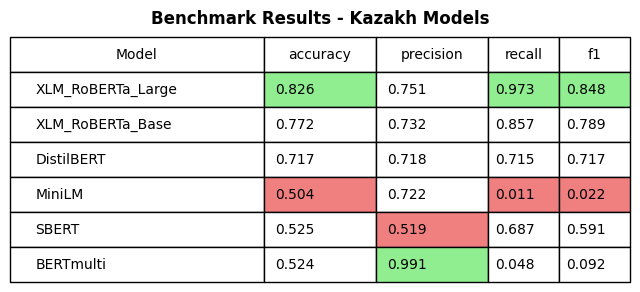

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the benchmark results
file_path = "/content/drive/MyDrive/new-datasets/benchmark_results_all_models_20K.csv"
df_all = pd.read_csv(file_path, index_col=0)

# Round numbers to three decimal places
df_all = df_all.round(3)

def highlight_best_worst(df_global, category):
    """
    Create a matplotlib table for 'df_subset' with:
      - Green for the best (max) value in each column within 'df_subset'.
      - Red for the worst (min) value in each column globally (df_global).
    """
    # Create a figure and axis
    fig, ax = plt.subplots(figsize=(8, 3.5))  # Adjust size as needed

    # Set title with increased pad to create space
    ax.set_title(
        f"Benchmark Results - {category} Models",
        fontsize=12,
        fontweight="bold",
        pad=10  # Increase this value for more vertical space
    )

    ax.axis("off")  # Hide the axis

    # Convert the subset DataFrame to a list of lists for the table
    table_data = [[idx] + row.tolist() for idx, row in df_global.iterrows()]

    # Column labels (first is "Model", rest are metrics)
    col_labels = ["Model"] + df_global.columns.tolist()

    # Create the table (left-align)
    table = ax.table(
        cellText=table_data,
        colLabels=col_labels,
        cellLoc="left",
        loc="center",
        bbox=[0, 0, 1, 1]  # Fill the entire Axes
    )

    # Highlight logic
    for col_idx in range(1, len(df_global.columns) + 1):
        df_col_idx = col_idx - 1
        column_values_subset = df_global.iloc[:, df_col_idx]
        max_val_subset = column_values_subset.max()

        column_values_global = df_global.iloc[:, df_col_idx]
        min_val_global = column_values_global.min()

        for row_idx in range(len(df_global)):
            cell = table[row_idx + 1, col_idx]
            cell_value = df_global.iloc[row_idx, df_col_idx]
            if cell_value == max_val_subset:
                cell.set_facecolor("lightgreen")
            if cell_value == min_val_global:
                cell.set_facecolor("lightcoral")

    # Font size adjustments
    table.auto_set_font_size(False)
    table.set_fontsize(10)

    # Make columns fit the text
    for i in range(len(col_labels)):
        table.auto_set_column_width(col=i)

    # Adjust layout => lowering 'top' can create more space at the top
    plt.subplots_adjust(top=0.75, bottom=0.05)

    return fig

# Plot results for Kazakh models
fig_kazakh = highlight_best_worst(df_all, "Kazakh")
plt.show(fig_kazakh)

In [ ]:
!pip install seaborn


Generating Benchmark Visualizations...


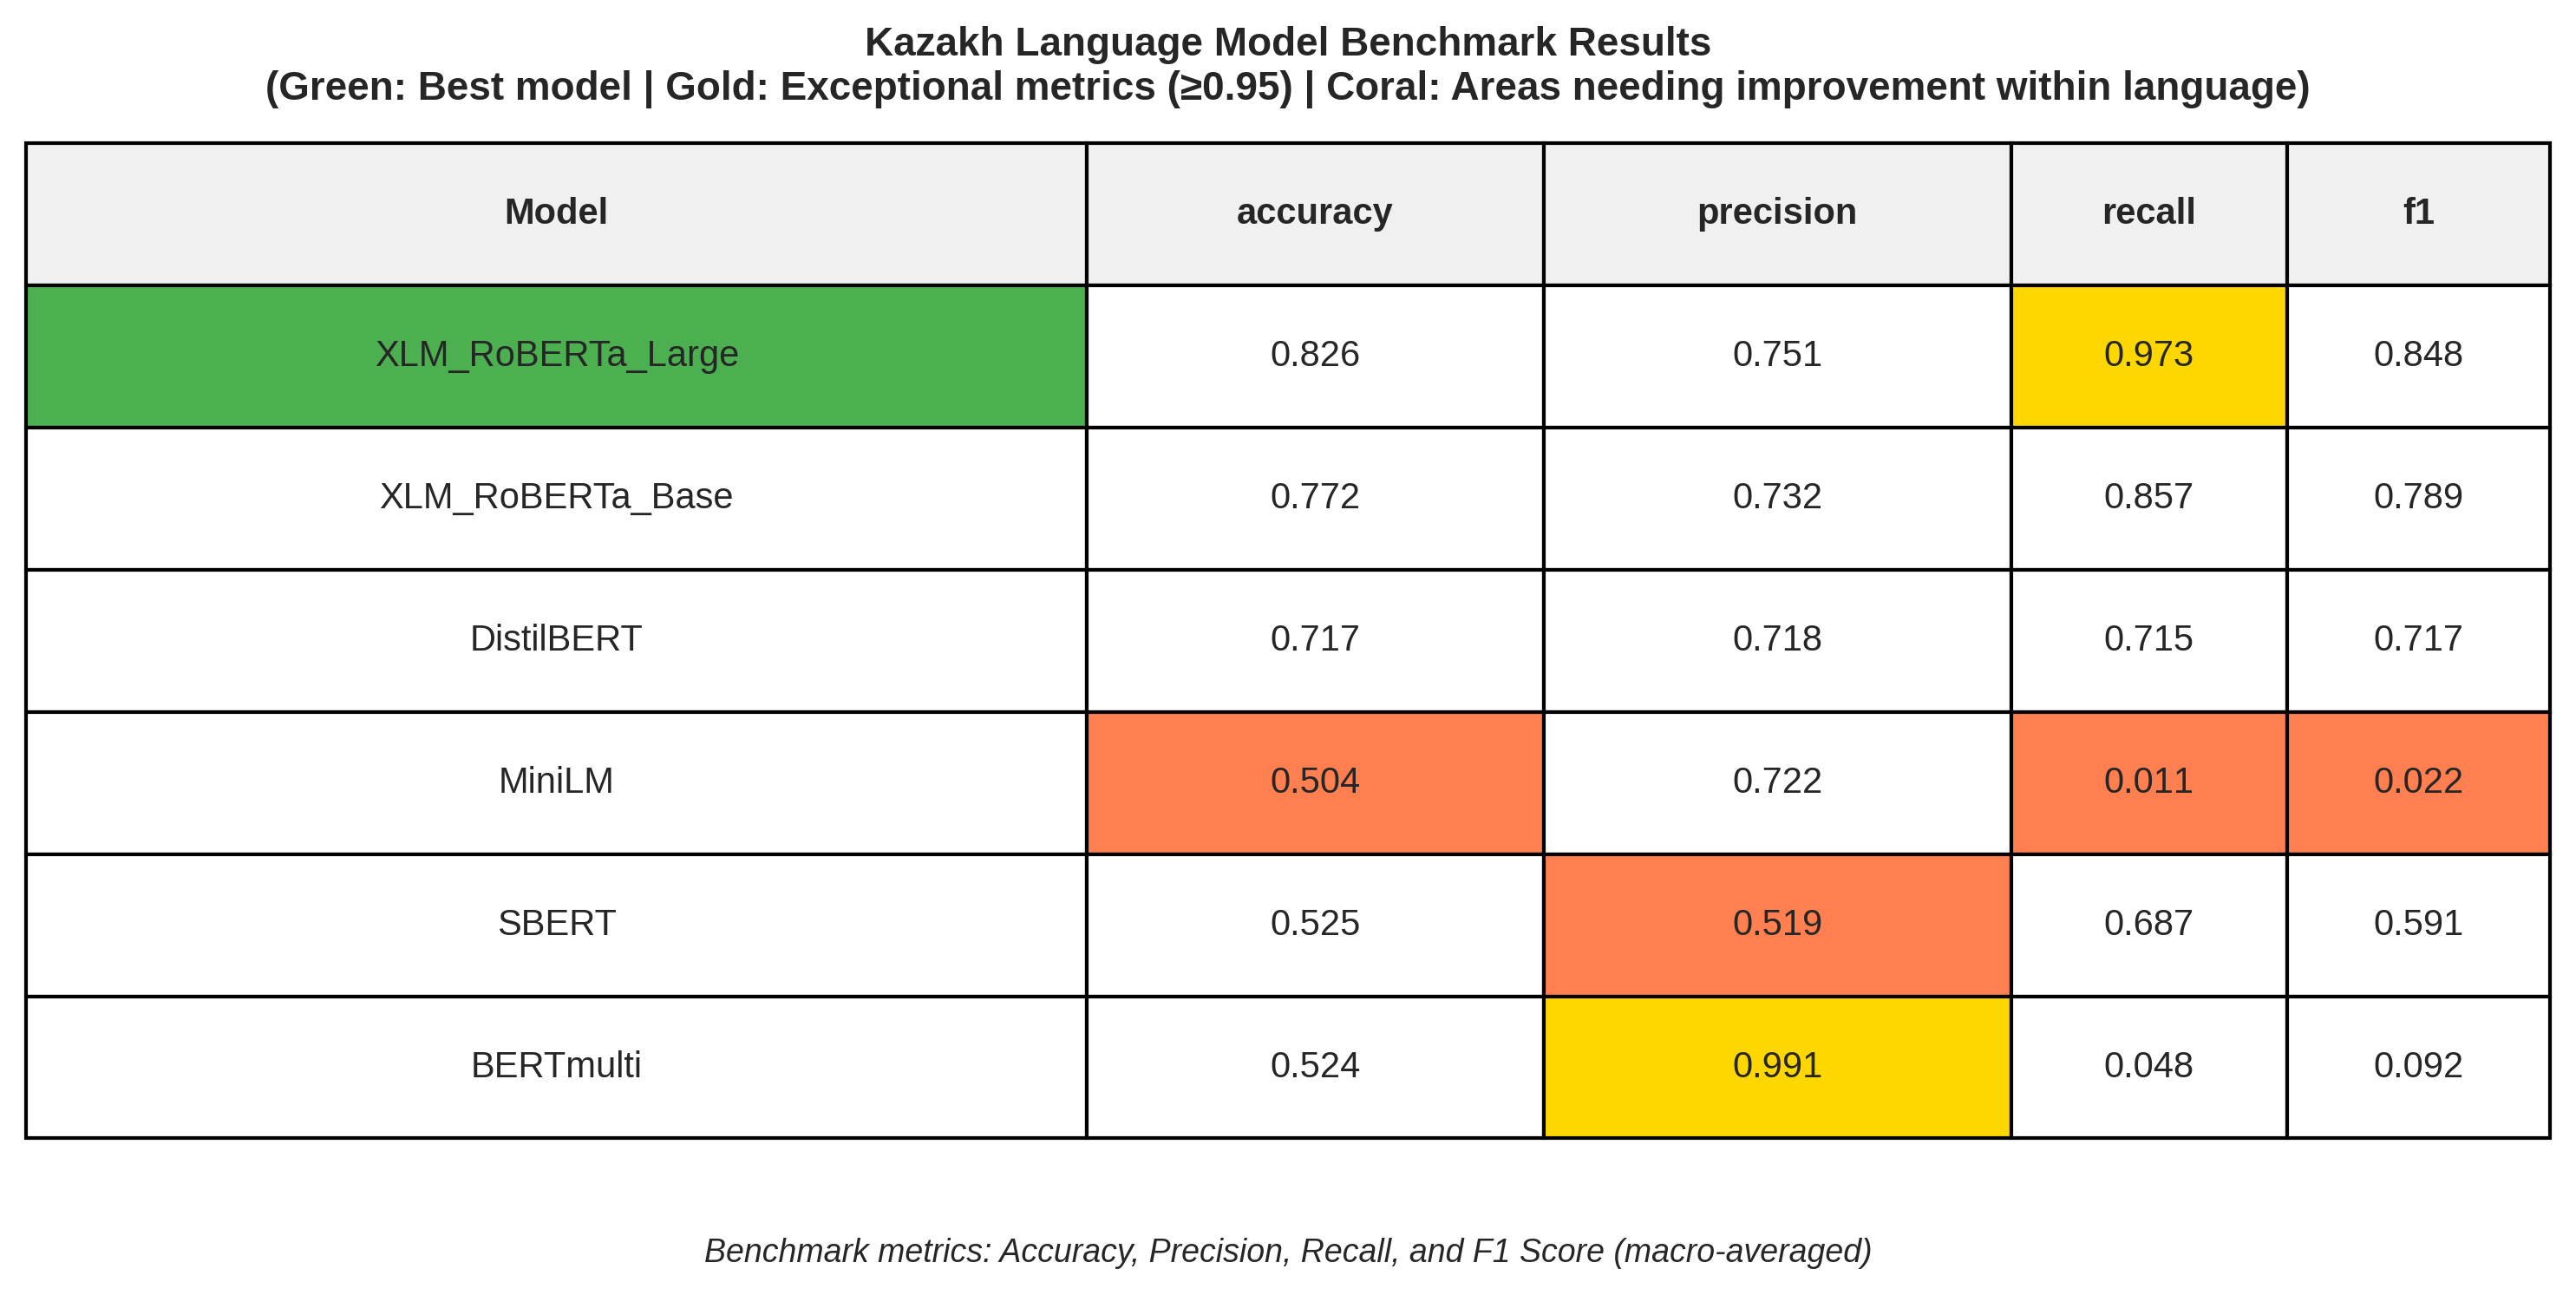

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import numpy as np

# Set professional font and style
mpl.rcParams['font.family'] = 'DejaVu Sans'
plt.style.use('seaborn-v0_8-whitegrid')

# Load benchmark results
file_path = "/content/drive/MyDrive/new-datasets/benchmark_results_all_models_20K.csv"
df_all = pd.read_csv(file_path, index_col=0).round(3)

def create_benchmark_table(df_subset, language):
    """
    Creates publication-quality benchmark table with:
    - Green highlight for best model (by F1 score)
    - Gold highlight for exceptional metrics (≥0.95)
    - Coral highlight for worst metrics within this language group
    """
    # Initialize figure with research paper dimensions
    fig, ax = plt.subplots(figsize=(10, 5), dpi=300)

    # Professional title with metrics explanation
    title = (
        f"{language} Language Model Benchmark Results\n"
        "(Green: Best model | Gold: Exceptional metrics (≥0.95) | "
        "Coral: Areas needing improvement within language)"
    )
    ax.set_title(title, fontsize=11, pad=12, fontweight='semibold')
    ax.axis('off')

    if df_subset.empty:
        print(f"No {language} models found.")
        return fig

    # Prepare table data with model names
    table_data = [[idx] + row.tolist() for idx, row in df_subset.iterrows()]
    columns = ["Model"] + df_subset.columns.tolist()

    # Create table with professional styling
    table = ax.table(
        cellText=table_data,
        colLabels=columns,
        cellLoc='center',
        loc='center',
        bbox=[0, 0.1, 1, 0.9]
    )

    # Custom color palette
    best_model_color = '#4CAF50'  # Green
    exceptional_color = '#FFD700'  # Gold
    concern_color = '#FF7F50'     # Coral
    header_color = '#F0F0F0'      # Light gray

    # Style column headers
    for col in range(len(columns)):
        table[0, col].set_facecolor(header_color)
        table[0, col].set_text_props(weight='bold')

    # Highlight single best model by F1 score
    if not df_subset.empty:
        best_model_idx = df_subset['f1'].idxmax()
        best_row_idx = df_subset.index.get_loc(best_model_idx)
        table[best_row_idx+1, 0].set_facecolor(best_model_color)

    # Metric-specific highlighting
    for col_idx, metric in enumerate(df_subset.columns, 1):
        metric_values = df_subset[metric]
        language_min = df_subset[metric].min()

        for row_idx in range(len(df_subset)):
            value = df_subset.iloc[row_idx, col_idx-1]
            cell = table[row_idx+1, col_idx]

            # Highlight exceptional metrics in gold
            if value >= 0.95:
                cell.set_facecolor(exceptional_color)
            # Highlight worst within language in coral
            elif value == language_min:
                cell.set_facecolor(concern_color)

    # Professional typography
    table.auto_set_font_size(False)
    table.set_fontsize(10)

    # Column width adjustment
    for col in range(len(columns)):
        table.auto_set_column_width(col=col)

    # Add methodological footnote
    plt.figtext(
        0.5, 0.02,
        "Benchmark metrics: Accuracy, Precision, Recall, and F1 Score (macro-averaged)",
        ha='center',
        fontsize=9,
        style='italic'
    )

    plt.tight_layout()
    return fig

# Generate publication-ready figures
print("\nGenerating Benchmark Visualizations...")
kz_fig = create_benchmark_table(df_all, "Kazakh")

# Display with tight layout
plt.show(kz_fig)

# Save publication-quality figures
kz_fig.savefig("kz_benchmarks.pdf", bbox_inches='tight', dpi=300)

### 📝 **Conclusion**

#### 🔍 Purpose of English Model Training

Although the primary goal of this study is to improve **plagiarism detection for the Kazakh language**, we initially trained and evaluated the **XLM-RoBERTa Large model** on both **Kazakh** and **English** datasets. This comparative experiment was conducted **not to build English models**, but to **highlight the performance disparity** between a **high-resource language (English)** and a **low-resource language (Kazakh)** on the same task using the same architecture.

#### 📊 Cross-Language Benchmark Results (XLM-RoBERTa Large)

| Model Version           | Language | Accuracy | Precision | Recall | F1 Score |
| ----------------------- | -------- | -------- | --------- | ------ | -------- |
| `kz-xlm-roberta-20K-v2` | Kazakh   | 0.8255   | 0.7514    | 0.9728 | 0.8479   |
| `en-xlm-roberta-20K-v2` | English  | 0.9963   | 1.0000    | 0.9925 | 0.9963   |

These results confirm a significant **performance gap** between the English and Kazakh versions, primarily due to the **lack of large-scale pretraining data and annotated resources** for the Kazakh language.

#### 🧪 Kazakh Model Benchmark Comparison

To address this gap, we trained several transformer-based models **exclusively on Kazakh data** and evaluated them on the same Kazakh test set:

| Model Name        | Accuracy | Precision | Recall | F1 Score |
| ----------------- | -------- | --------- | ------ | -------- |
| XLM-RoBERTa Large | 0.8255   | 0.7514    | 0.9728 | 0.8479   |
| XLM-RoBERTa Base  | 0.7716   | 0.7321    | 0.8566 | 0.7895   |
| DistilBERT        | 0.7172   | 0.7180    | 0.7155 | 0.7167   |
| MiniLM            | 0.5035   | 0.7222    | 0.0114 | 0.0224   |
| SBERT             | 0.5252   | 0.5191    | 0.6865 | 0.5912   |
| BERTmulti         | 0.5239   | 0.9910    | 0.0482 | 0.0920   |


* **XLM-RoBERTa Large** achieved the **highest F1 score** (0.8479) among all Kazakh-trained models, demonstrating its strong ability to capture nuanced semantic similarity in low-resource contexts.
* The **performance drop** compared to English (F1 = 0.9963) clearly illustrates the challenges of **low-resource language processing**.
* Simpler or distilled models like **MiniLM**, **SBERT**, and **BERTmulti** failed to generalize well, indicating that **larger, multilingual pretraining** remains crucial for Kazakh.

📌 **Final Decision**:
We will use the **XLM-RoBERTa Large model trained on the Kazakh dataset** as the **primary model** for our plagiarism detection system due to its superior performance.
